## Fitting classifiers

In [1]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, RobustScaler, FunctionTransformer, OneHotEncoder, MinMaxScaler
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
    learning_curve,
)
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
)
from sklearn import set_config
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
original_df = pd.read_csv('tracks2026.csv')
df = original_df.copy()
df

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5xmO5SbFOiVrRGrMQhL4Jk,44.0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,5cF0dROlMOK5uNZtivgu50,83.0,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,4OQ9XGe11ckizN2EBnNED2,49.0,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,6Grw9OtoslF9JrDJ6pgsQG,0.0,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,3fGpNiwYr981n72YY4DZvB,41.0,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,4pcpqfSn8tfm6vQMMZPjpM,25.0,266133,False,0.794,0.919,9,-3.037,1,0.0619,0.1540,0.000000,0.2480,0.963,133.550,4,synth-pop
1996,1WM80A5a4xDtlndjqjZQIv,52.0,223236,False,0.667,0.629,0,-8.493,1,0.0324,0.1750,0.116000,0.0915,0.455,115.002,4,synth-pop
1997,4drUfuJw6c9M5cXA8p7upO,0.0,162009,False,0.541,0.753,0,-6.512,1,0.0511,0.0677,0.000000,0.1080,0.572,149.743,4,indie-pop
1998,6ULjJomtdRstnT9BPMAf9d,58.0,120000,False,0.853,0.511,7,-6.451,0,0.4220,0.1880,0.000000,0.2230,0.795,90.171,4,hip-hop


In [3]:
# Drop NaN values and trackid
df = df.dropna()
df = df.drop(columns = ["track_id"])
df

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,44.0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,83.0,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,49.0,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,0.0,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,41.0,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,25.0,266133,False,0.794,0.919,9,-3.037,1,0.0619,0.1540,0.000000,0.2480,0.963,133.550,4,synth-pop
1996,52.0,223236,False,0.667,0.629,0,-8.493,1,0.0324,0.1750,0.116000,0.0915,0.455,115.002,4,synth-pop
1997,0.0,162009,False,0.541,0.753,0,-6.512,1,0.0511,0.0677,0.000000,0.1080,0.572,149.743,4,indie-pop
1998,58.0,120000,False,0.853,0.511,7,-6.451,0,0.4220,0.1880,0.000000,0.2230,0.795,90.171,4,hip-hop


In [4]:
# Encode explicit-column
map_cat = {False: 0, True: 1}
df[['explicit']] = df[['explicit']].replace(map_cat)
df

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,44.0,203337,0,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,83.0,208786,0,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,49.0,262373,0,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,0.0,191733,0,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,41.0,283706,0,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,25.0,266133,0,0.794,0.919,9,-3.037,1,0.0619,0.1540,0.000000,0.2480,0.963,133.550,4,synth-pop
1996,52.0,223236,0,0.667,0.629,0,-8.493,1,0.0324,0.1750,0.116000,0.0915,0.455,115.002,4,synth-pop
1997,0.0,162009,0,0.541,0.753,0,-6.512,1,0.0511,0.0677,0.000000,0.1080,0.572,149.743,4,indie-pop
1998,58.0,120000,0,0.853,0.511,7,-6.451,0,0.4220,0.1880,0.000000,0.2230,0.795,90.171,4,hip-hop


In [5]:
# New target variable. This could be seen as a data leak, but as median is global and quite robust, we can the median of the whole dataset.
median_popularity = df["popularity"].median()
df['popularity_binary'] = df["popularity"].apply(lambda x: 0 if x <= median_popularity else 1)
df = df.drop(columns=["popularity"])
# X and y
y = df['popularity_binary']
X = df.drop(columns=["popularity_binary"])
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y)

In [6]:
# Let us perform the preprosessing, same as in data preparation

# Define column groups
numerical_cols = X.select_dtypes(include=[np.number]).columns
categorical_numerical = ['key', 'mode', 'time_signature', 'explicit']  # numerical but categorical
continuous_numerical = [col for col in numerical_cols if col not in categorical_numerical]

no_outlier_cols = ['valence', 'acousticness']
outlier_cols = [col for col in continuous_numerical if col not in no_outlier_cols]
passthrough_cols = [col for col in df.columns if col not in continuous_numerical]

# Split outlier columns into negative and positive value groups
outlier_cols_neg = [col for col in outlier_cols if df[col].min() < 0]
outlier_cols_pos = [col for col in outlier_cols if df[col].min() >= 0]

# Pipelines
preprocess_no_outliers = Pipeline([
    ('log', FunctionTransformer(func=np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

preprocess_outliers_neg = Pipeline([
    ('scaler', RobustScaler())  
])
preprocess_outliers_pos = Pipeline([
     ('log', FunctionTransformer(func=np.log1p, feature_names_out='one-to-one')),
     ('scaler', RobustScaler())
])
# Scale key and time_signature columns, as they have different scale than others
key_timesignature_cols = ["key", "time_signature"]
key_timesignature_pipeline = Pipeline(steps = [
    ('scaler', StandardScaler())
])
minmax_pipeline = Pipeline(steps = [
    ('log', FunctionTransformer(func=np.log1p, feature_names_out='one-to-one')),
    ('scaler', MinMaxScaler())
])
# Do OneHotEncoding here to avoid test set containing information about the track-genre categories in training set. 
# If unknown value, ignore
onehotencode_pipeline = Pipeline(steps = [
    ("onehotencode", OneHotEncoder(handle_unknown='ignore'))
])
preprocess_pipeline = ColumnTransformer(
    transformers=[
        ('no_outliers', preprocess_no_outliers, no_outlier_cols),
        ('outliers_neg', preprocess_outliers_neg, outlier_cols_neg),
        ('outliers_pos', preprocess_outliers_pos, outlier_cols_pos),
        ('key_time_signature', key_timesignature_pipeline, key_timesignature_cols),
        ("onehotencode", onehotencode_pipeline, ["track_genre"] )
    ],
    remainder='passthrough'
)
print(no_outlier_cols)
print(outlier_cols_neg)
print(outlier_cols_pos)
print(key_timesignature_cols)



['valence', 'acousticness']
['loudness']
['duration_ms', 'danceability', 'energy', 'speechiness', 'instrumentalness', 'liveness', 'tempo']
['key', 'time_signature']


In [7]:
# Fit the pipe to training data to inspect how transformed features look like
preprocessing_results = preprocess_pipeline.fit_transform(X_train)

In [8]:
# Put transformed values into a dataframe
feature_names = preprocess_pipeline.get_feature_names_out()
df_transformed = pd.DataFrame(
    preprocessing_results,
    columns=feature_names
)
df_transformed

,no_outliers__valence,no_outliers__acousticness,outliers_neg__loudness,outliers_pos__duration_ms,outliers_pos__danceability,outliers_pos__energy,outliers_pos__speechiness,outliers_pos__instrumentalness,outliers_pos__liveness,outliers_pos__tempo,key_time_signature__key,key_time_signature__time_signature,onehotencode__track_genre_hip-hop,onehotencode__track_genre_indie-pop,onehotencode__track_genre_pop,onehotencode__track_genre_r-n-b,onehotencode__track_genre_synth-pop,remainder__explicit,remainder__mode
0,1.635914,1.355406,0.618335,-0.501836,0.566524,0.581229,0.172037,-0.01031,-0.569335,-0.30984,-0.930496,0.216649,0.0,0.0,0.0,1.0,0.0,0,0
1,0.791984,-0.700272,0.161433,-0.291648,0.943613,0.335208,0.370541,-0.01031,1.592526,-0.237976,1.324555,0.216649,1.0,0.0,0.0,0.0,0.0,1,0
2,1.55735,-0.301715,-0.496944,0.74884,0.452132,-0.23451,-0.423813,-0.001889,0.485044,-0.269325,-0.930496,0.216649,0.0,0.0,0.0,0.0,1.0,0,1
3,-0.759253,-0.928481,-0.481489,1.588526,-0.611725,-0.541355,-0.266438,384.368959,1.626776,-0.137868,-0.930496,0.216649,0.0,0.0,0.0,0.0,1.0,0,0
4,-0.655985,1.510354,-1.340218,0.507578,-0.975748,-1.538041,-0.438758,25.623158,0.024465,0.47101,0.478911,0.216649,0.0,1.0,0.0,0.0,0.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1563,-2.055852,-0.220527,-0.574499,-1.136393,-0.476965,-0.317318,-0.494359,48.957791,0.105545,-0.339501,-1.494259,0.216649,0.0,0.0,0.0,0.0,1.0,0,1
1564,0.29818,-1.136698,-1.722655,-0.065077,-1.349534,-0.075929,-0.340731,0.163008,0.539097,-1.131959,1.042673,0.216649,0.0,0.0,0.0,1.0,0.0,0,0
1565,-0.985625,0.535117,-0.04229,-0.06101,0.752279,-0.275769,0.140857,0.031386,-0.202278,-0.504754,0.760792,0.216649,0.0,0.0,1.0,0.0,0.0,0,0
1566,0.346129,0.517843,0.158623,-0.040131,-0.471396,0.338602,-0.453714,0.125403,4.020033,0.477777,0.478911,0.216649,0.0,0.0,0.0,1.0,0.0,0,1


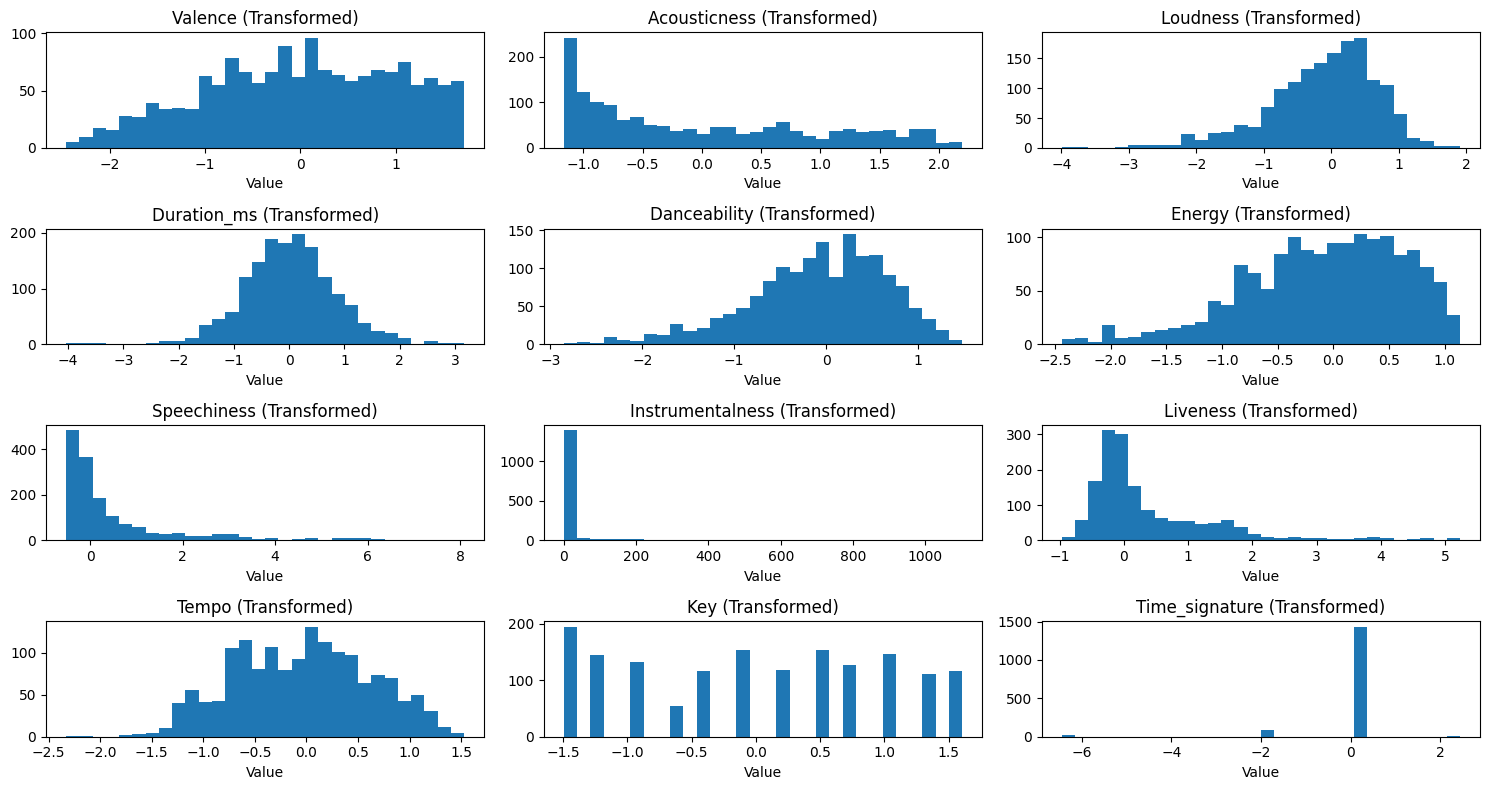

In [9]:
# Plot the TRANSFORMED data (not 0/1 values)
fig, axes = plt.subplots(4, 3, figsize=(15, 8))
axes[0, 0].hist(df_transformed['no_outliers__valence'], bins=30)
axes[0, 0].set_title('Valence (Transformed)')
axes[0, 0].set_xlabel('Value')

axes[0, 1].hist(df_transformed['no_outliers__acousticness'], bins=30)
axes[0, 1].set_title('Acousticness (Transformed)')
axes[0, 1].set_xlabel('Value')

axes[0, 2].hist(df_transformed['outliers_neg__loudness'], bins=30)
axes[0, 2].set_title('Loudness (Transformed)')
axes[0, 2].set_xlabel('Value')

axes[1, 0].hist(df_transformed['outliers_pos__duration_ms'], bins=30)
axes[1, 0].set_title('Duration_ms (Transformed)')
axes[1, 0].set_xlabel('Value')

axes[1, 1].hist(df_transformed['outliers_pos__danceability'], bins=30)
axes[1, 1].set_title('Danceability (Transformed)')
axes[1, 1].set_xlabel('Value')

axes[1, 2].hist(df_transformed['outliers_pos__energy'], bins=30)
axes[1, 2].set_title('Energy (Transformed)')
axes[1, 2].set_xlabel('Value')

axes[2, 0].hist(df_transformed['outliers_pos__speechiness'], bins=30)
axes[2, 0].set_title('Speechiness (Transformed)')
axes[2, 0].set_xlabel('Value')

axes[2, 1].hist(df_transformed['outliers_pos__instrumentalness'], bins=30)
axes[2, 1].set_title('Instrumentalness (Transformed)')
axes[2, 1].set_xlabel('Value')

axes[2, 2].hist(df_transformed['outliers_pos__liveness'], bins=30)
axes[2, 2].set_title('Liveness (Transformed)')
axes[2, 2].set_xlabel('Value')

axes[3, 0].hist(df_transformed['outliers_pos__tempo'], bins=30)
axes[3, 0].set_title('Tempo (Transformed)')
axes[3, 0].set_xlabel('Value')

axes[3, 1].hist(df_transformed['key_time_signature__key'], bins=30)
axes[3, 1].set_title('Key (Transformed)')
axes[3, 1].set_xlabel('Value')

axes[3, 2].hist(df_transformed['key_time_signature__time_signature'], bins=30)
axes[3, 2].set_title('Time_signature (Transformed)')
axes[3, 2].set_xlabel('Value')
plt.tight_layout()
plt.show()

In [10]:
# Cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = {
    "F1-score": "f1",
    "Precision": "precision",
    "Recall": "recall",
    "ROC_AUC": "roc_auc",
    "AP": "average_precision"
}

In [11]:
# SVM  (slow af, don't know why)
pipe = Pipeline(steps=[("preprocess", preprocess_pipeline), ("svm", svm.SVC(probability=True))])

# Parameter grid
param_grid = {
    'svm__C': [0.1],
    'svm__gamma': [1],
    'svm__kernel': ['linear']
}

# Note that hyperparameters of the preprocessing transformers can also be included
# in the parameter grid. For simplicity, we do not tune them here.

svm_search = GridSearchCV(
    pipe,
    param_grid,
    n_jobs=-1,
    cv=cv,
    scoring=scoring,
    refit="F1-score",
    return_train_score=False
)
svm_search.fit(X_train, y_train)

print(f"Best CV F1 = {svm_search.best_score_:.3f}")
print("Best parameters: ", svm_search.best_params_)

# store the best params and best model for later use
SVM_best_params = svm_search.best_params_
SVM_best_model = svm_search.best_estimator_
SVM_best_cv_f1 = svm_search.best_score_

Best CV F1 = 0.650
Best parameters:  {'svm__C': 0.1, 'svm__gamma': 1, 'svm__kernel': 'linear'}


In [12]:
# Random forest
pipe = Pipeline(steps=[("preprocess", preprocess_pipeline), ("r_forest", RandomForestClassifier())])
# Parameter grid
param_grid = {
    'r_forest__n_estimators': [10, 20, 30, 40],
    'r_forest__max_depth': [2, 4, 6, 8, 10, 12]
}

r_forest_search = GridSearchCV(
    pipe,
    param_grid,
    n_jobs=-1,
    cv=cv,
    scoring=scoring,
    refit="F1-score",
    return_train_score=False
)
r_forest_search.fit(X_train, y_train) 

print(f"Best CV F1 = {r_forest_search.best_score_:.3f}")
print("Best parameters: ", r_forest_search.best_params_)

# store the best params and best model for later use
r_forest_best_params = r_forest_search.best_params_
r_forest_best_model = r_forest_search.best_estimator_
r_forest_best_cv_f1 = r_forest_search.best_score_

Best CV F1 = 0.718
Best parameters:  {'r_forest__max_depth': 12, 'r_forest__n_estimators': 30}


In [13]:
# Gaussian (Normal) Naive Bayes
pipe = Pipeline(steps=[("preprocess", preprocess_pipeline), ("naive_bayes", GaussianNB())])
# Parameter grid
param_grid = {
    'naive_bayes__var_smoothing': [0.00000001, 0.00001, 0.001, 0.1]
}

NB_search = GridSearchCV(
    pipe,
    param_grid,
    n_jobs=-1,
    cv=cv,
    scoring=scoring,
    refit="F1-score",
    return_train_score=False
)
NB_search.fit(X_train, y_train) 

print(f"Best CV F1 = {NB_search.best_score_:.3f}")
print("Best parameters: ", NB_search.best_params_)

# store the best params and best model for later use
NB_best_params = NB_search.best_params_
NB_best_model = NB_search.best_estimator_
NB_best_cv_f1 = NB_search.best_score_

Best CV F1 = 0.635
Best parameters:  {'naive_bayes__var_smoothing': 1e-08}


In [14]:
# Logistic regression
pipe = Pipeline(steps=[("preprocess", preprocess_pipeline), ("logistic_reg", LogisticRegression())])
# Parameter grid, parameters suggested by Gemini
param_grid = {
    'logistic_reg__C': [0.01, 0.1, 1, 10, 100],
    'logistic_reg__penalty': ['l1', 'l2'],
    'logistic_reg__solver': ["liblinear", "saga"]
}

logistic_reg_search = GridSearchCV(
    pipe,
    param_grid,
    n_jobs=-1,
    cv=cv,
    scoring=scoring,
    refit="F1-score",
    return_train_score=False
)
logistic_reg_search.fit(X_train, y_train) 

print(f"Best CV F1 = {logistic_reg_search.best_score_:.3f}")
print("Best parameters: ", logistic_reg_search.best_params_)

# store the best params and best model for later use
logistic_reg_best_params = logistic_reg_search.best_params_
logistic_reg_best_model = logistic_reg_search.best_estimator_
logistic_reg_best_cv_f1 = logistic_reg_search.best_score_

/home/studium/Dokumente/my-jupyter-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/studium/Dokumente/my-jupyter-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/studium/Dokumente/my-jupyter-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=

Best CV F1 = 0.626
Best parameters:  {'logistic_reg__C': 0.1, 'logistic_reg__penalty': 'l2', 'logistic_reg__solver': 'liblinear'}


/home/studium/Dokumente/my-jupyter-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [15]:
# Gradient Boosting Classifier
pipe = Pipeline(steps=[("preprocess", preprocess_pipeline), ("grad_boost", GradientBoostingClassifier())])
# Parameter grid, parameters suggested by Gemini
param_grid = {
    'grad_boost__learning_rate': [0.05, 0.1],
    'grad_boost__n_estimators': [100, 400],
    'grad_boost__max_depth': [3, 5],
    'grad_boost__min_samples_split': [2, 5],
    'grad_boost__subsample': [0.8,1.0]
}

grad_boost_search = GridSearchCV(
    pipe,
    param_grid,
    n_jobs=-1,
    cv=cv,
    scoring=scoring,
    refit="F1-score",
    return_train_score=False
)
grad_boost_search.fit(X_train, y_train) 

print(f"Best CV F1 = {grad_boost_search.best_score_:.3f}")
print("Best parameters: ", grad_boost_search.best_params_)

# store the best params and best model for later use
grad_boost_best_params = grad_boost_search.best_params_
grad_boost_best_model = grad_boost_search.best_estimator_
grad_boost_best_cv_f1 = grad_boost_search.best_score_

Best CV F1 = 0.713
Best parameters:  {'grad_boost__learning_rate': 0.1, 'grad_boost__max_depth': 5, 'grad_boost__min_samples_split': 2, 'grad_boost__n_estimators': 100, 'grad_boost__subsample': 0.8}


In [16]:
# Copied from the lab-exercise
# Compute CV metrics (mean ± std) for the *best* SVM, random forest and naive bayes models
models = {
    "SVM (best by F1)": SVM_best_model,
    "Random Forest (best by F1)": r_forest_best_model,
    "Gaussian Naive Bayes (best by F1)": NB_best_model,
    "Logistic regression (best by F1)": logistic_reg_best_model,
    "Gradient Boosting (best by F1)": grad_boost_best_model
}

cv_results = {}

for name, model in models.items():
    res = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    cv_results[name] = {m: res[f"test_{m}"] for m in scoring.keys()}

# Print a concise summary
for name, metrics_dict in cv_results.items():
    print("\n" + name)
    for m, vals in metrics_dict.items():
        print(f"  {m:9s}: mean={np.mean(vals):.3f}, std={np.std(vals):.3f}")



/home/studium/Dokumente/my-jupyter-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/studium/Dokumente/my-jupyter-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/studium/Dokumente/my-jupyter-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in versi


SVM (best by F1)
  F1-score : mean=0.650, std=0.029
  Precision: mean=0.576, std=0.021
  Recall   : mean=0.747, std=0.050
  ROC_AUC  : mean=0.652, std=0.031
  AP       : mean=0.623, std=0.028

Random Forest (best by F1)
  F1-score : mean=0.715, std=0.019
  Precision: mean=0.721, std=0.029
  Recall   : mean=0.710, std=0.021
  ROC_AUC  : mean=0.786, std=0.027
  AP       : mean=0.761, std=0.033

Gaussian Naive Bayes (best by F1)
  F1-score : mean=0.635, std=0.030
  Precision: mean=0.580, std=0.019
  Recall   : mean=0.704, std=0.054
  ROC_AUC  : mean=0.648, std=0.025
  AP       : mean=0.611, std=0.027

Logistic regression (best by F1)
  F1-score : mean=0.626, std=0.043
  Precision: mean=0.608, std=0.032
  Recall   : mean=0.647, std=0.060
  ROC_AUC  : mean=0.652, std=0.032
  AP       : mean=0.630, std=0.032

Gradient Boosting (best by F1)
  F1-score : mean=0.708, std=0.027
  Precision: mean=0.710, std=0.037
  Recall   : mean=0.706, std=0.030
  ROC_AUC  : mean=0.767, std=0.034
  AP       : 

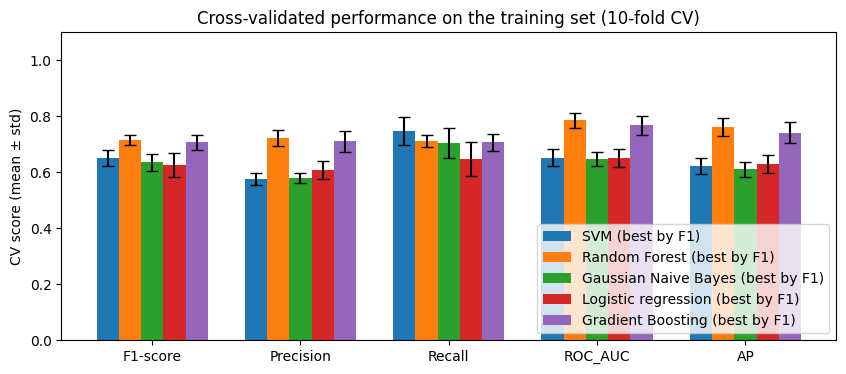

In [17]:
# Copied from the lab-exercise
# Plot of the mean and std of the metrics of different classifiers
metric_names = list(scoring.keys())
labels = list(cv_results.keys())

# means and stds
means = {lab: [np.mean(cv_results[lab][m]) for m in metric_names] for lab in labels}
stds  = {lab: [np.std(cv_results[lab][m]) for m in metric_names] for lab in labels}

x = np.arange(len(metric_names))
width = 0.15

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width*2, means[labels[0]], width, yerr=stds[labels[0]], capsize=4, label=labels[0])
ax.bar(x - width, means[labels[1]], width, yerr=stds[labels[1]], capsize=4, label=labels[1])
ax.bar(x , means[labels[2]], width, yerr=stds[labels[2]], capsize=4, label=labels[2])
ax.bar(x + width, means[labels[3]], width, yerr=stds[labels[3]], capsize=4, label=labels[3])
ax.bar(x + width*2, means[labels[4]], width, yerr=stds[labels[4]], capsize=4, label=labels[4])

ax.set_xticks(x)
ax.set_xticklabels(metric_names, rotation=0)
ax.set_ylim(0, 1.1)
ax.set_ylabel("CV score (mean ± std)")
ax.set_title("Cross-validated performance on the training set (10-fold CV)")
ax.legend(loc="lower right")
plt.show()


### ROC curve

/home/studium/Dokumente/my-jupyter-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/studium/Dokumente/my-jupyter-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/studium/Dokumente/my-jupyter-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in versi

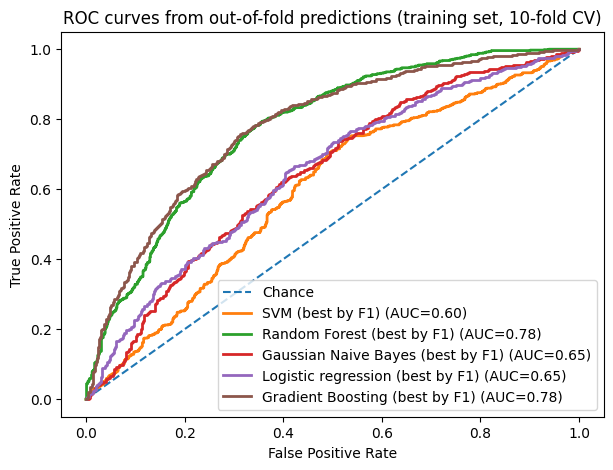

In [18]:
# Copied from the lab-exercise
# Out-of-fold ROC curves for the two best models (training set only)
plt.figure(figsize=(7, 5))
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")

for name, model in models.items():
    # Out-of-fold probability for class 1 (each point predicted by a model that did not train on it)
    oof_proba = cross_val_predict(model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

    fpr, tpr, _ = roc_curve(y_train, oof_proba)
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc_val:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves from out-of-fold predictions (training set, 10-fold CV)")
plt.legend(loc="lower right")
plt.show()


### Precision-Recall curve

/home/studium/Dokumente/my-jupyter-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/studium/Dokumente/my-jupyter-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/studium/Dokumente/my-jupyter-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in versi

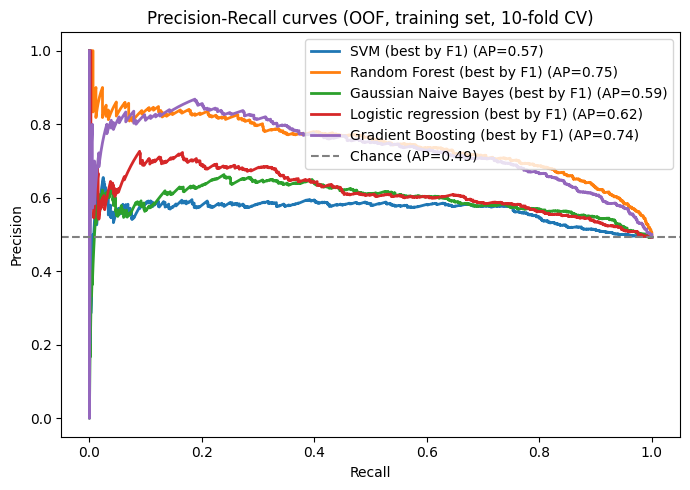

In [19]:
# PR curves — out-of-fold predictions (training set, all models)
plt.figure(figsize=(7, 5))

for name, model in models.items():
    oof_proba = cross_val_predict(model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
    prec, rec, _ = precision_recall_curve(y_train, oof_proba)
    ap = average_precision_score(y_train, oof_proba)
    plt.plot(rec, prec, lw=2, label=f"{name} (AP={ap:.2f})")

baseline = y_train.mean()
plt.axhline(baseline, linestyle="--", color="grey", label=f"Chance (AP={baseline:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves (OOF, training set, 10-fold CV)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Evaluation by exercise notebook

In [20]:
best_model = r_forest_best_model
best_name = "Random Forest"
best_cv_f1 = r_forest_best_cv_f1

In [21]:
# Copied from the lab-exercise
def evaluate_model(X_eval, y_eval, model):
    # predicted probabilities for class 1
    probabilities = model.predict_proba(X_eval)[:, 1]

    # predicted class labels
    predicted = model.predict(X_eval)

    # confusion matrix
    cm = confusion_matrix(y_eval, predicted)

    # metrics
    acc = accuracy_score(y_eval, predicted)
    prec = precision_score(y_eval, predicted, zero_division=0)
    rec = recall_score(y_eval, predicted, zero_division=0)
    f1 = f1_score(y_eval, predicted, zero_division=0)

    # ROC curve + AUC
    fpr, tpr, _ = roc_curve(y_eval, probabilities)
    auc_val = auc(fpr, tpr)

    # PR curve + average_precision
    prc_precision, prc_recall, _ = precision_recall_curve(y_eval, probabilities)
    prc_ap = average_precision_score(y_eval, probabilities)

    return cm, acc, prec, rec, f1, fpr, tpr, auc_val, prc_precision, prc_recall, prc_ap
# Final evaluation on the held-out test set (used once for reporting)
test_cm, test_accuracy, test_precision, test_recall, test_f1_score, test_fpr, test_tpr, test_auc, test_prc_precision, test_prc_recall, test_prc_ap = evaluate_model(X_test, y_test, best_model)
cm_df = pd.DataFrame(
    test_cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

print("Confusion Matrix (Test Set):")
display(cm_df)

Confusion Matrix (Test Set):


,Predicted 0,Predicted 1
Actual 0,142,57
Actual 1,57,136


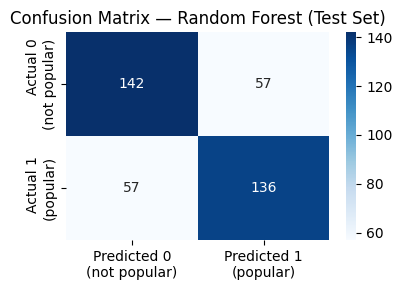

In [22]:
# Confusion matrix as heatmap
fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(
    test_cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted 0\n(not popular)', 'Predicted 1\n(popular)'],
    yticklabels=['Actual 0\n(not popular)', 'Actual 1\n(popular)'],
    ax=ax
)
ax.set_title(f'Confusion Matrix — {best_name} (Test Set)')
plt.tight_layout()
plt.show()

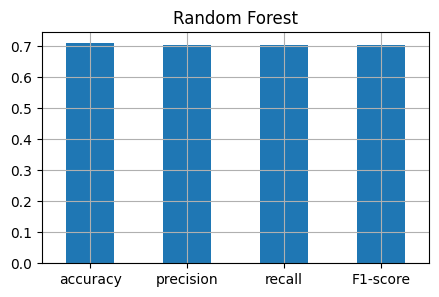

In [23]:
# Copied from the lab-exercise
metrics = np.array([test_accuracy, test_precision, test_recall, test_f1_score])
index = ['accuracy', 'precision', 'recall', 'F1-score']
df_metrics = pd.DataFrame({best_name: metrics}, index=index)
df_metrics.plot.bar(rot=0, figsize=(5, 3), legend=False, title=f"{best_name}")
plt.grid()
plt.show()

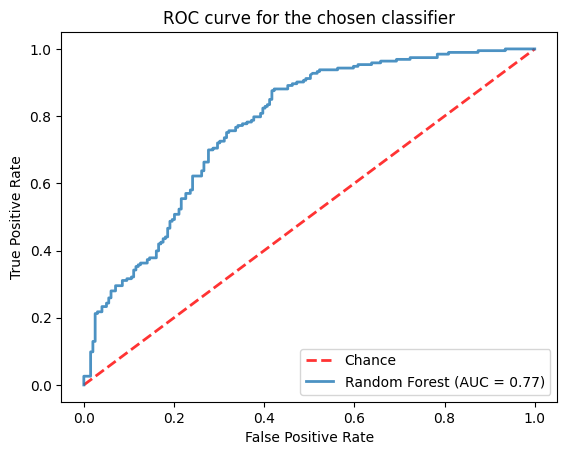

In [24]:
# Copied from the lab-exercise
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=0.8)
plt.plot(test_fpr, test_tpr, lw=2, label=f'{best_name} (AUC = {test_auc:0.2f})', alpha=0.8)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve for the chosen classifier')
plt.legend(loc="lower right")
plt.show()

### Test-Set Evaluation — all models

The table below compares all five models on the held-out test set (used only once for final reporting). The best value per metric is highlighted in green. This allows direct comparison with the CV results above and helps identify any models that overfit (high CV score but lower test score).

In [25]:
# Test-set evaluation for all models — summary table
all_test_results = []
for name, model in models.items():
    cm_, acc, prec, rec, f1, fpr_, tpr_, auc_val, _, _, ap = evaluate_model(X_test, y_test, model)
    all_test_results.append({
        "Model":      name,
        "Accuracy":   round(acc, 3),
        "Precision":  round(prec, 3),
        "Recall":     round(rec, 3),
        "F1-score":   round(f1, 3),
        "ROC AUC":    round(auc_val, 3),
        "Avg. Prec.": round(ap, 3),
    })

results_df = pd.DataFrame(all_test_results).set_index("Model")
display(results_df.style.highlight_max(axis=0, color='lightgreen').format("{:.3f}"))

,Accuracy,Precision,Recall,F1-score,ROC AUC,Avg. Prec.
Model,,,,,,
SVM (best by F1),0.645,0.603,0.819,0.695,0.676,0.629
Random Forest (best by F1),0.709,0.705,0.705,0.705,0.773,0.734
Gaussian Naive Bayes (best by F1),0.633,0.600,0.762,0.671,0.679,0.618
Logistic regression (best by F1),0.651,0.624,0.731,0.673,0.705,0.656
Gradient Boosting (best by F1),0.712,0.702,0.720,0.711,0.764,0.716


## Conclusion
Best model is Random Forest, providing approximately 70% accuracy, recall, precision and F1-score

## Feature importance
Let us use a method for model-agnostic global feature importance

In [28]:
# Use permutation_importance, same way as in example. Let us do same to each model to get the complete picture.
r_forest_feature_importance_result = permutation_importance(
    r_forest_best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
SVM_feature_importance_result = permutation_importance(
    SVM_best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
logistic_reg_feature_importance_result = permutation_importance(
    logistic_reg_best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
grad_boost_feature_importance_result = permutation_importance(
    grad_boost_best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
NB_feature_importance_result = permutation_importance(
    NB_best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [29]:
# Turn importances to pd.Series
feature_names = X_test.columns
r_forest_importances = pd.Series(r_forest_feature_importance_result.importances_mean, index=feature_names).sort_values(ascending=False)
grad_boost_importances = pd.Series(grad_boost_feature_importance_result.importances_mean, index=feature_names).sort_values(ascending=False)
NB_importances = pd.Series(NB_feature_importance_result.importances_mean, index=feature_names).sort_values(ascending=False)
logistic_reg_importances = pd.Series(logistic_reg_feature_importance_result.importances_mean, index=feature_names).sort_values(ascending=False)
SVM_importances = pd.Series(SVM_feature_importance_result.importances_mean, index=feature_names).sort_values(ascending=False)

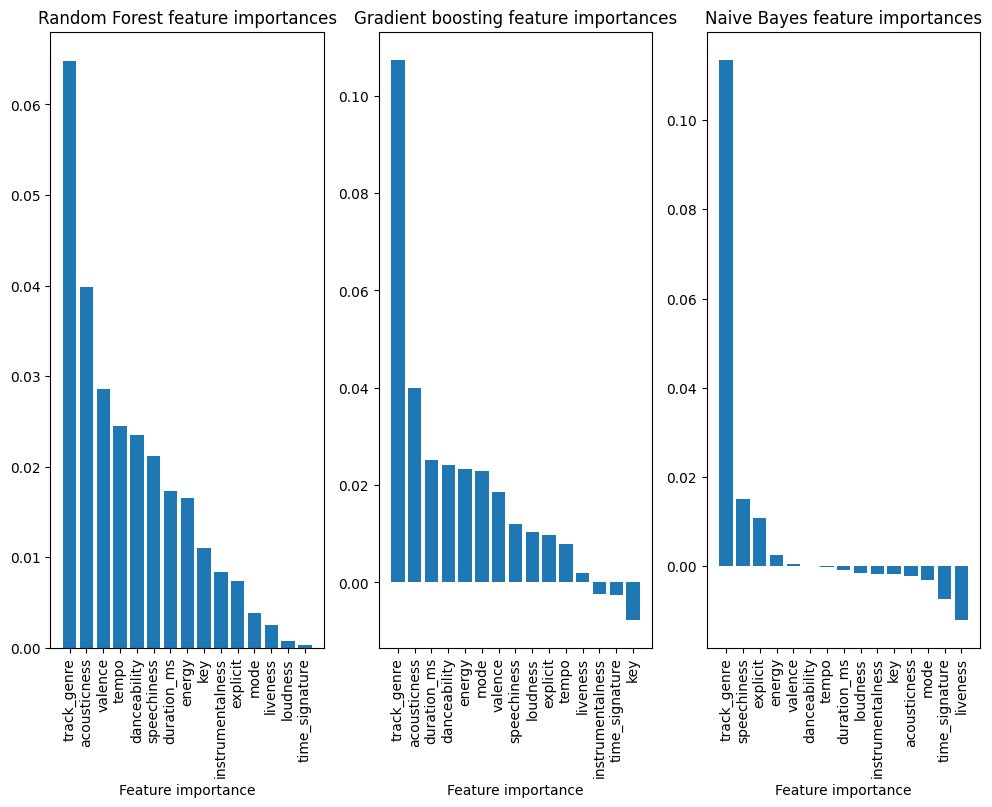

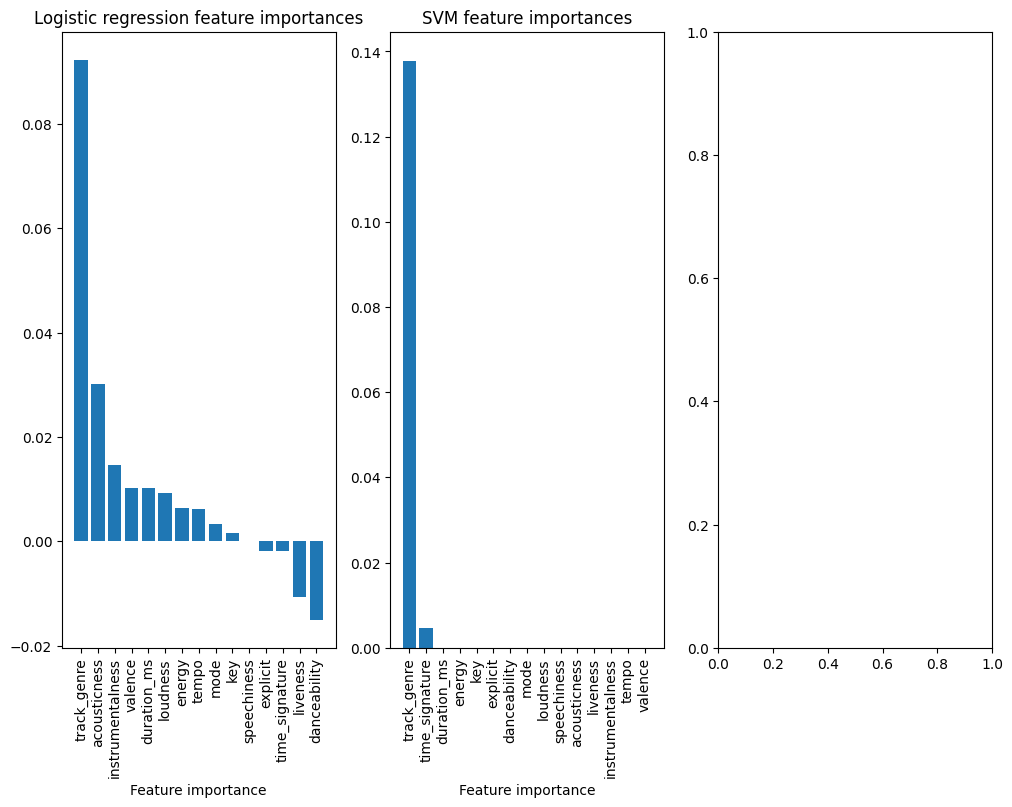

Feature importances of random forest model


track_genre         0.064796
acousticness        0.039796
valence             0.028571
tempo               0.024490
danceability        0.023469
speechiness         0.021173
duration_ms         0.017347
energy              0.016582
key                 0.010969
instrumentalness    0.008418
explicit            0.007398
mode                0.003827
liveness            0.002551
loudness            0.000765
time_signature      0.000255
dtype: float64

In [31]:
# Plot importances
fig, axes = plt.subplots(1, 3, figsize=(12, 8))
axes[0].bar(r_forest_importances.index, r_forest_importances)
axes[0].set_title('Random Forest feature importances')
axes[0].set_xlabel('Feature importance')
axes[0].tick_params(axis='x', labelrotation=90)
axes[1].bar(grad_boost_importances.index, grad_boost_importances)
axes[1].set_title('Gradient boosting feature importances')
axes[1].set_xlabel('Feature importance')
axes[1].tick_params(axis='x', labelrotation=90)
axes[2].bar(NB_importances.index, NB_importances)
axes[2].set_title('Naive Bayes feature importances')
axes[2].set_xlabel('Feature importance')
axes[2].tick_params(axis='x', labelrotation=90)
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 8))
axes2[0].bar(logistic_reg_importances.index, logistic_reg_importances)
axes2[0].set_title('Logistic regression feature importances')
axes2[0].set_xlabel('Feature importance')
axes2[0].tick_params(axis='x', labelrotation=90)
axes2[1].bar(SVM_importances.index,SVM_importances)
axes2[1].set_title('SVM feature importances')
axes2[1].set_xlabel('Feature importance')
axes2[1].tick_params(axis='x', labelrotation=90)
plt.show()
print("Feature importances of random forest model")
r_forest_importances

### Interpretation of feature importances of all models
As can be seen, track_genre is influencing the most to each of the model performance. Thus, it suggests that it has impact on the prediction of whether or not a song is popular.

### Interpretation of the feature importance of random forest model
Feature 'track_genre' seems to have the highest impact to the model performance, if it is shuffled (0.09). Also, features 'acousticness', 'tempo' and danceability seem to have higher importance than rest of the features. Shuffling of any feature do not lead to model performance decrease.